In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import Ridge

In [22]:
#df_lic = pd.read_parquet("data/data_licences/data_licences.parquet")
df = pd.read_parquet("data/data_complet.parquet")

In [23]:
df.head()

,code_2024,code_annee_n,codes_2016_2024,federation,annee,sexe,age,tranche_age,grande_tranche_age,region,...,2016_or,2024_argent,2020_argent,2016_argent,2024_bronze,2020_bronze,2016_bronze,total_medailles_2016,total_medailles_2020,total_medailles_2024
0,101,101,101,Fédération Française d'Athlétisme,2016,F,5,b - de 5 à 9 ans,1 - Enfants (1-13),84 - Auvergne-Rhône-Alpes,...,0.0,1.0,1.0,3.0,0.0,0.0,3.0,6.0,1.0,1.0
1,101,101,101,Fédération Française d'Athlétisme,2016,F,6,b - de 5 à 9 ans,1 - Enfants (1-13),84 - Auvergne-Rhône-Alpes,...,0.0,1.0,1.0,3.0,0.0,0.0,3.0,6.0,1.0,1.0
2,101,101,101,Fédération Française d'Athlétisme,2016,F,7,b - de 5 à 9 ans,1 - Enfants (1-13),84 - Auvergne-Rhône-Alpes,...,0.0,1.0,1.0,3.0,0.0,0.0,3.0,6.0,1.0,1.0
3,101,101,101,Fédération Française d'Athlétisme,2016,F,8,b - de 5 à 9 ans,1 - Enfants (1-13),84 - Auvergne-Rhône-Alpes,...,0.0,1.0,1.0,3.0,0.0,0.0,3.0,6.0,1.0,1.0
4,101,101,101,Fédération Française d'Athlétisme,2016,F,9,b - de 5 à 9 ans,1 - Enfants (1-13),84 - Auvergne-Rhône-Alpes,...,0.0,1.0,1.0,3.0,0.0,0.0,3.0,6.0,1.0,1.0


In [24]:
# renomme la colonne nb_lic
df_agg = df.copy()

df_agg = df_agg.rename(columns={
    'licences_annuelles': 'nb_licencies'
})


df_agg = (
    df_agg
    .groupby(['code_sport', 'annee'], as_index=False)
    .agg({
        'nb_licencies': 'sum'
    })
)

In [ ]:
#on rajoute une colonne (qui correspond aux dernier jo)
def jo_reference(annee):
    if annee < 2020: ## atttention il faut que je mette <= 2020  ra les jo ont eu lieu en 2021
        return 2016
    elif annee < 2024:
        return 2020
    else:
        return 2024

df_agg['jo_ref'] = df_agg['annee'].apply(jo_reference)

In [26]:
df_agg.head()

,code_sport,annee,nb_licencies,jo_ref
0,ATH,2016,301976,2016
1,ATH,2017,307018,2016
2,ATH,2018,314692,2016
3,ATH,2019,316749,2016
4,ATH,2020,305914,2020


In [ ]:
#### pb dataset trop gros
# garder une seule ligne par sport
df_sport = df.drop_duplicates(subset=["code_sport"])[
    ["code_sport","sport",
     "2016_or","2016_argent","2016_bronze","total_medailles_2016",
     "2020_or","2020_argent","2020_bronze","total_medailles_2020",
     "2024_or","2024_argent","2024_bronze","total_medailles_2024"]
]

# construire df_med (sport x jo_ref) => petit 
df_med = pd.concat([
    df_sport[["code_sport","sport","2016_or","2016_argent","2016_bronze","total_medailles_2016"]]
        .rename(columns={"2016_or":"or","2016_argent":"argent","2016_bronze":"bronze","total_medailles_2016":"total_medailles"})
        .assign(jo_ref=2016),

    df_sport[["code_sport","sport","2020_or","2020_argent","2020_bronze","total_medailles_2020"]]
        .rename(columns={"2020_or":"or","2020_argent":"argent","2020_bronze":"bronze","total_medailles_2020":"total_medailles"})
        .assign(jo_ref=2020),

    df_sport[["code_sport","sport","2024_or","2024_argent","2024_bronze","total_medailles_2024"]]
        .rename(columns={"2024_or":"or","2024_argent":"argent","2024_bronze":"bronze","total_medailles_2024":"total_medailles"})
        .assign(jo_ref=2024),
], ignore_index=True)

print("df_sport shape:", df_sport.shape)
print("df_med shape:", df_med.shape)
df_med.head()


df_sport shape: (34, 14)
df_med shape: (102, 7)


,code_sport,sport,or,argent,bronze,total_medailles,jo_ref
0,ATH,Athlétisme,0.0,3.0,3.0,6.0,2016
1,AVI,Aviron,1.0,0.0,1.0,2.0,2016
2,BAD,Badminton,0.0,0.0,0.0,0.0,2016
3,BAK,Basket-ball,0.0,0.0,0.0,0.0,2016
4,BOX,Boxe,2.0,2.0,2.0,6.0,2016


In [56]:
df_model = df_agg.merge(
    df_med[["code_sport", "jo_ref", "or", "argent", "bronze", "total_medailles"]],
    on=["code_sport", "jo_ref"],
    how="left"
)

# si un sport n'a pas de médailles : 0
for c in ["or", "argent", "bronze", "total_medailles"]:
    df_model[c] = df_model[c].fillna(0)

print("df_model shape:", df_model.shape)
df_model.head()


df_model shape: (306, 8)


,code_sport,annee,nb_licencies,jo_ref,or,argent,bronze,total_medailles
0,ATH,2016,301976,2016,0.0,3.0,3.0,6.0
1,ATH,2017,307018,2016,0.0,3.0,3.0,6.0
2,ATH,2018,314692,2016,0.0,3.0,3.0,6.0
3,ATH,2019,316749,2016,0.0,3.0,3.0,6.0
4,ATH,2020,305914,2020,0.0,1.0,0.0,1.0


In [ ]:
print("df_agg shape :", df_agg.shape)
print("df_model shape:", df_model.shape)

# le nombre de lignes doit être identique après left merge
assert len(df_model) == len(df_agg), " Le merge a changé le nombre de lignes !"
print(" Même nombre de lignes : left join OK")


df_agg shape : (306, 4)
df_model shape: (306, 8)
 Même nombre de lignes : left join OK


In [59]:
def safe_div(a, b):
    return np.where(b == 0, 0.0, a / b)

def build_lic_features(df_lic: pd.DataFrame) -> pd.DataFrame:
    df = df_lic.copy()

    # --- colonnes requises
    required = ["code_sport", "annee", "licences_annuelles"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Colonnes manquantes dans df: {missing}")

    # --- types
    df["annee"] = pd.to_numeric(df["annee"], errors="coerce").astype("int16")
    df["licences_annuelles"] = pd.to_numeric(df["licences_annuelles"], errors="coerce").fillna(0.0)

    # --- colonnes optionnelles
    if "sexe" not in df.columns:
        df["sexe"] = "U"
    if "age" not in df.columns:
        df["age"] = np.nan
    if "grande_tranche_age" not in df.columns:
        df["grande_tranche_age"] = "Unknown"
    if "code_dep" not in df.columns:
        df["code_dep"] = "00"

    # --- flags sexe
    df["is_femme"] = (df["sexe"] == "F").astype("int8")
    df["is_homme"] = (df["sexe"] == "H").astype("int8")

    # --- buckets âge
    df["age"] = pd.to_numeric(df["age"], errors="coerce")
    df["is_jeune_lt14"]  = ((df["age"] < 14) & df["age"].notna()).astype("int8")
    df["is_jeune_14_17"] = ((df["age"] >= 14) & (df["age"] <= 17)).astype("int8")
    df["is_adulte_18_34"] = ((df["age"] >= 18) & (df["age"] <= 34)).astype("int8")
    df["is_adulte_35_49"] = ((df["age"] >= 35) & (df["age"] <= 49)).astype("int8")
    df["is_senior_50p"]   = ((df["age"] >= 50)).astype("int8")

    # ======================================================
    # 1) Base : nb_licencies (sport, annee)
    # ======================================================
    base = (
        df.groupby(["code_sport", "annee"], as_index=False)
          .agg(nb_licencies=("licences_annuelles", "sum"))
    )

    # ======================================================
    # 2) Sexe : nb_femmes / nb_hommes (vectorisé)
    # ======================================================
    df["lic_femmes"] = df["licences_annuelles"] * df["is_femme"]
    df["lic_hommes"] = df["licences_annuelles"] * df["is_homme"]

    sex = (
        df.groupby(["code_sport", "annee"], as_index=False)
          .agg(nb_femmes=("lic_femmes", "sum"),
               nb_hommes=("lic_hommes", "sum"))
    )

    # ======================================================
    # 3) Âge : moyenne pondérée + std pondérée + comptes par classes
    # ======================================================
    # moyenne pondérée
    df["_w_age"] = df["licences_annuelles"].where(df["age"].notna(), 0.0)
    df["_wa"] = (df["age"].fillna(0.0) * df["_w_age"])
    df["_wa2"] = ((df["age"].fillna(0.0) ** 2) * df["_w_age"])

    age_agg = (
        df.groupby(["code_sport", "annee"], as_index=False)
          .agg(
              w_sum=("_w_age", "sum"),
              wa_sum=("_wa", "sum"),
              wa2_sum=("_wa2", "sum"),
              nb_lt14=("licences_annuelles", lambda s: 0.0),  # placeholder
          )
    )

    # comptes par buckets (plus simple via colonnes pondérées)
    df["lic_lt14"]  = df["licences_annuelles"] * df["is_jeune_lt14"]
    df["lic_14_17"] = df["licences_annuelles"] * df["is_jeune_14_17"]
    df["lic_18_34"] = df["licences_annuelles"] * df["is_adulte_18_34"]
    df["lic_35_49"] = df["licences_annuelles"] * df["is_adulte_35_49"]
    df["lic_50p"]   = df["licences_annuelles"] * df["is_senior_50p"]

    age_counts = (
        df.groupby(["code_sport", "annee"], as_index=False)
          .agg(
              nb_lt14=("lic_lt14", "sum"),
              nb_14_17=("lic_14_17", "sum"),
              nb_18_34=("lic_18_34", "sum"),
              nb_35_49=("lic_35_49", "sum"),
              nb_50p=("lic_50p", "sum"),
          )
    )

    age_stats = age_agg.merge(age_counts, on=["code_sport", "annee"], how="left")

    age_stats["age_mean"] = np.where(
        age_stats["w_sum"] > 0,
        age_stats["wa_sum"] / age_stats["w_sum"],
        np.nan
    )
    age_stats["age2_mean"] = np.where(
        age_stats["w_sum"] > 0,
        age_stats["wa2_sum"] / age_stats["w_sum"],
        np.nan
    )
    var = (age_stats["age2_mean"] - age_stats["age_mean"] ** 2).clip(lower=0)
    age_stats["age_std"] = np.sqrt(var)

    age_stats = age_stats.drop(columns=["w_sum", "wa_sum", "wa2_sum", "age2_mean"])

    # ======================================================
    # 4) Grande tranche (pivot)
    # ======================================================
    tranche = (
        df.groupby(["code_sport", "annee", "grande_tranche_age"], as_index=False)
          .agg(tranche_lic=("licences_annuelles", "sum"))
    )

    tranche_wide = (
        tranche.pivot_table(
            index=["code_sport", "annee"],
            columns="grande_tranche_age",
            values="tranche_lic",
            aggfunc="sum",
            fill_value=0.0
        )
        .reset_index()
    )

    tranche_cols = [c for c in tranche_wide.columns if c not in ["code_sport", "annee"]]
    tranche_wide = tranche_wide.rename(
        columns={c: f"tranche_{str(c).strip().lower().replace(' ', '_')}" for c in tranche_cols}
    )

    # ======================================================
    # 5) Géographie : nb deps actifs + herfindahl
    # ======================================================
    dep_sum = (
        df.groupby(["code_sport", "annee", "code_dep"], as_index=False)
          .agg(dep_lic=("licences_annuelles", "sum"))
    )

    # nb deps actifs
    dep_active = (
        dep_sum.groupby(["code_sport", "annee"], as_index=False)
               .agg(nb_departements_actifs=("dep_lic", lambda s: (s > 0).sum()),
                    dep_total=("dep_lic", "sum"))
    )

    dep_sum = dep_sum.merge(dep_active[["code_sport", "annee", "dep_total"]], on=["code_sport", "annee"], how="left")
    dep_sum["share2"] = safe_div(dep_sum["dep_lic"], dep_sum["dep_total"]) ** 2

    herf = (
        dep_sum.groupby(["code_sport", "annee"], as_index=False)
               .agg(herfindahl_dep=("share2", "sum"))
    )

    dept_feat = dep_active.drop(columns=["dep_total"]).merge(herf, on=["code_sport", "annee"], how="left")

    # ======================================================
    # 6) Merge final
    # ======================================================
    out = (
        base.merge(sex, on=["code_sport", "annee"], how="left")
            .merge(age_stats, on=["code_sport", "annee"], how="left")
            .merge(tranche_wide, on=["code_sport", "annee"], how="left")
            .merge(dept_feat, on=["code_sport", "annee"], how="left")
    )

    # parts
    out["part_femmes"] = safe_div(out["nb_femmes"], out["nb_licencies"])
    out["part_hommes"] = safe_div(out["nb_hommes"], out["nb_licencies"])

    out["part_lt14"]  = safe_div(out["nb_lt14"], out["nb_licencies"])
    out["part_14_17"] = safe_div(out["nb_14_17"], out["nb_licencies"])
    out["part_18_34"] = safe_div(out["nb_18_34"], out["nb_licencies"])
    out["part_35_49"] = safe_div(out["nb_35_49"], out["nb_licencies"])
    out["part_50p"]   = safe_div(out["nb_50p"], out["nb_licencies"])

    # ======================================================
    # 7) Lags + dynamiques (comme ton code)
    # ======================================================
    out = out.sort_values(["code_sport", "annee"]).reset_index(drop=True)

    for lag in [1, 2]:
        out[f"nb_licencies_lag{lag}"] = out.groupby("code_sport")["nb_licencies"].shift(lag)
        out[f"part_femmes_lag{lag}"] = out.groupby("code_sport")["part_femmes"].shift(lag)
        out[f"age_mean_lag{lag}"] = out.groupby("code_sport")["age_mean"].shift(lag)

    out["croissance_lag1"] = safe_div(out["nb_licencies"] - out["nb_licencies_lag1"], out["nb_licencies_lag1"])
    out["croissance_lag2"] = safe_div(out["nb_licencies_lag1"] - out["nb_licencies_lag2"], out["nb_licencies_lag2"])

    out["nb_licencies_roll2"] = (
        out.groupby("code_sport")["nb_licencies"]
           .shift(1)
           .rolling(2)
           .mean()
           .reset_index(level=0, drop=True)
    )

    return out


In [61]:
import numpy as np
import pandas as pd

def safe_div(a, b):
    return np.where(b == 0, 0.0, a / b)

def build_lic_features(df_lic: pd.DataFrame) -> pd.DataFrame:
    df = df_lic.copy()

    # --- sanity
    required = ["code_sport", "annee", "licences_annuelles"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Colonnes manquantes dans df: {missing}")

    # types
    df["annee"] = df["annee"].astype(int)
    df["licences_annuelles"] = pd.to_numeric(df["licences_annuelles"], errors="coerce").fillna(0.0)

    # optionnelles
    if "sexe" not in df.columns:
        df["sexe"] = "U"
    if "age" not in df.columns:
        df["age"] = np.nan
    if "grande_tranche_age" not in df.columns:
        df["grande_tranche_age"] = "Unknown"
    if "code_dep" not in df.columns:
        df["code_dep"] = "00"

    # flags sexe
    df["is_femme"] = (df["sexe"] == "F").astype(int)
    df["is_homme"] = (df["sexe"] == "H").astype(int)

    # buckets âge
    df["age"] = pd.to_numeric(df["age"], errors="coerce")
    df["is_jeune_lt14"]  = ((df["age"] < 14) & df["age"].notna()).astype(int)
    df["is_jeune_14_17"] = ((df["age"] >= 14) & (df["age"] <= 17)).astype(int)
    df["is_adulte_18_34"] = ((df["age"] >= 18) & (df["age"] <= 34)).astype(int)
    df["is_adulte_35_49"] = ((df["age"] >= 35) & (df["age"] <= 49)).astype(int)
    df["is_senior_50p"]   = ((df["age"] >= 50)).astype(int)

    # --- aggregate totals per sport-year
    g = df.groupby(["code_sport", "annee"], as_index=False)

    base = g.agg(nb_licencies=("licences_annuelles", "sum"))

    # sexe
    sex = (
        df.groupby(["code_sport", "annee"])
          .apply(lambda x: pd.Series({
              "nb_femmes": (x["licences_annuelles"] * x["is_femme"]).sum(),
              "nb_hommes": (x["licences_annuelles"] * x["is_homme"]).sum(),
          }))
          .reset_index()
    )

    # âge stats + comptes
    def _age_block(x):
        w = x["licences_annuelles"].to_numpy(dtype=float)
        a = x["age"].to_numpy(dtype=float)

        mask = ~np.isnan(a)
        w2 = w[mask]
        a2 = a[mask]

        if w2.sum() == 0:
            age_mean = np.nan
            age_std = np.nan
        else:
            age_mean = float((a2 * w2).sum() / w2.sum())
            age2_mean = float(((a2 ** 2) * w2).sum() / w2.sum())
            var = max(0.0, age2_mean - age_mean ** 2)
            age_std = float(np.sqrt(var))

        nb_lt14  = float(x.loc[x["is_jeune_lt14"] == 1, "licences_annuelles"].sum())
        nb_14_17 = float(x.loc[x["is_jeune_14_17"] == 1, "licences_annuelles"].sum())
        nb_18_34 = float(x.loc[x["is_adulte_18_34"] == 1, "licences_annuelles"].sum())
        nb_35_49 = float(x.loc[x["is_adulte_35_49"] == 1, "licences_annuelles"].sum())
        nb_50p   = float(x.loc[x["is_senior_50p"] == 1, "licences_annuelles"].sum())

        return pd.Series({
            "age_mean": age_mean,
            "age_std": age_std,
            "nb_lt14": nb_lt14,
            "nb_14_17": nb_14_17,
            "nb_18_34": nb_18_34,
            "nb_35_49": nb_35_49,
            "nb_50p": nb_50p,
        })

    age_stats = (
        df.groupby(["code_sport", "annee"])
          .apply(_age_block)
          .reset_index()
    )

    # grande_tranche_age pivot
    tranche = (
        df.groupby(["code_sport", "annee", "grande_tranche_age"], as_index=False)
          .agg(tranche_lic=("licences_annuelles", "sum"))
    )

    tranche_wide = (
        tranche.pivot_table(
            index=["code_sport", "annee"],
            columns="grande_tranche_age",
            values="tranche_lic",
            aggfunc="sum",
            fill_value=0.0
        )
        .reset_index()
    )

    tranche_cols = [c for c in tranche_wide.columns if c not in ["code_sport", "annee"]]
    tranche_wide = tranche_wide.rename(
        columns={c: f"tranche_{str(c).strip().lower().replace(' ', '_')}" for c in tranche_cols}
    )

    # géographie + herfindahl
    dept_sum = (
        df.groupby(["code_sport", "annee", "code_dep"], as_index=False)
          .agg(dep_lic=("licences_annuelles", "sum"))
    )

    dept_feat = (
        dept_sum.groupby(["code_sport", "annee"])
        .apply(lambda x: pd.Series({
            "nb_departements_actifs": int((x["dep_lic"] > 0).sum()),
            "herfindahl_dep": float((safe_div(x["dep_lic"].values, x["dep_lic"].sum()) ** 2).sum()) if x["dep_lic"].sum() > 0 else 0.0
        }))
        .reset_index()
    )

    # merge blocks
    out = (
        base.merge(sex, on=["code_sport", "annee"], how="left")
            .merge(age_stats, on=["code_sport", "annee"], how="left")
            .merge(tranche_wide, on=["code_sport", "annee"], how="left")
            .merge(dept_feat, on=["code_sport", "annee"], how="left")
    )

    # parts
    out["part_femmes"] = safe_div(out["nb_femmes"], out["nb_licencies"])
    out["part_hommes"] = safe_div(out["nb_hommes"], out["nb_licencies"])

    out["part_lt14"]  = safe_div(out["nb_lt14"], out["nb_licencies"])
    out["part_14_17"] = safe_div(out["nb_14_17"], out["nb_licencies"])
    out["part_18_34"] = safe_div(out["nb_18_34"], out["nb_licencies"])
    out["part_35_49"] = safe_div(out["nb_35_49"], out["nb_licencies"])
    out["part_50p"]   = safe_div(out["nb_50p"], out["nb_licencies"])

    # lags + dynamiques
    out = out.sort_values(["code_sport", "annee"]).reset_index(drop=True)

    for lag in [1, 2]:
        out[f"nb_licencies_lag{lag}"] = out.groupby("code_sport")["nb_licencies"].shift(lag)
        out[f"part_femmes_lag{lag}"] = out.groupby("code_sport")["part_femmes"].shift(lag)
        out[f"age_mean_lag{lag}"] = out.groupby("code_sport")["age_mean"].shift(lag)

    out["croissance_lag1"] = safe_div(out["nb_licencies"] - out["nb_licencies_lag1"], out["nb_licencies_lag1"])
    out["croissance_lag2"] = safe_div(out["nb_licencies_lag1"] - out["nb_licencies_lag2"], out["nb_licencies_lag2"])

    out["nb_licencies_roll2"] = (
        out.groupby("code_sport")["nb_licencies"]
           .shift(1)
           .rolling(2)
           .mean()
           .reset_index(level=0, drop=True)
    )

    return out



In [62]:
lic_feat = build_lic_features(df)
print("lic_feat shape:", lic_feat.shape)

df_model_full = df_model.merge(
    lic_feat.drop(columns=["nb_licencies"]),  # pour éviter doublon
    on=["code_sport", "annee"],
    how="left"
)

print("df_model_full shape:", df_model_full.shape)


lic_feat shape: (306, 35)
df_model_full shape: (306, 40)


In [63]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df_reg = df_model_full.sort_values(["code_sport", "annee"])

# cible log (robuste)
df_reg["log_lic"] = np.log1p(df_reg["nb_licencies"])

# trend
df_reg["trend"] = df_reg["annee"] - df_reg["annee"].min()

# on garde uniquement les lignes où le lag1 existe (sinon impossible)
df_reg = df_reg[df_reg["nb_licencies_lag1"].notna()]

# split
train_df = df_reg[(df_reg["annee"] >= 2016) & (df_reg["annee"] <= 2020)]
test_df  = df_reg[(df_reg["annee"] >= 2022) & (df_reg["annee"] <= 2024)]

print("Train years:", sorted(train_df["annee"].unique()), "| n =", len(train_df))
print("Test years :", sorted(test_df["annee"].unique()),  "| n =", len(test_df))

# features : tu peux en ajouter/enlever
features = [
    "nb_licencies_lag1",
    "trend",
    "or", "argent", "bronze", "total_medailles",
    "nb_med_last_jo",
    "part_femmes",
    "age_mean",
    "age_std",
    "nb_departements_actifs",
    "herfindahl_dep",
    "croissance_lag1",
    "nb_licencies_roll2",
]

# garder seulement celles qui existent
features = [c for c in features if c in df_reg.columns]
print("Features utilisées:", features)

# X/y
X_train = train_df[features].replace([np.inf, -np.inf], np.nan).fillna(0.0)
X_test  = test_df[features].replace([np.inf, -np.inf], np.nan).fillna(0.0)

y_train = train_df["log_lic"].values
y_test  = test_df["log_lic"].values

# modèle
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

pred_log = model.predict(X_test)

# retour niveau
pred_nb = np.expm1(pred_log)
y_true = test_df["nb_licencies"].values

print("\n=== PERFORMANCE GLOBALE (niveau nb_licencies) ===")
print("MAE :", mean_absolute_error(y_true, pred_nb))
print("RMSE:", np.sqrt(mean_squared_error(y_true, pred_nb)))
print("R²  :", r2_score(y_true, pred_nb))

# tableau résultats
preds = test_df[["code_sport", "annee", "nb_licencies"]].copy()
preds["pred_nb_licencies"] = pred_nb
preds["abs_err"] = np.abs(preds["nb_licencies"] - preds["pred_nb_licencies"])

preds.head()


Train years: [2017, 2018, 2019, 2020] | n = 136
Test years : [2022, 2023, 2024] | n = 102
Features utilisées: ['nb_licencies_lag1', 'trend', 'or', 'argent', 'bronze', 'total_medailles', 'part_femmes', 'age_mean', 'age_std', 'nb_departements_actifs', 'herfindahl_dep', 'croissance_lag1', 'nb_licencies_roll2']

=== PERFORMANCE GLOBALE (niveau nb_licencies) ===
MAE : 292329.42975898297
RMSE: 918697.1849871896
R²  : 0.385836425067006


,code_sport,annee,nb_licencies,pred_nb_licencies,abs_err
6,ATH,2022,302583,238722.082983,63860.917017
7,ATH,2023,307021,222884.664612,84136.335388
8,ATH,2024,313957,222580.968016,91376.031984
15,AVI,2022,44951,88806.870558,43855.870558
16,AVI,2023,45332,82555.561375,37223.561375


In [64]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

d = df_model_full.sort_values(["code_sport","annee"]).copy()

# log + croissance (Δlog)
d["log_lic"] = np.log1p(d["nb_licencies"])
d["dlog_lic"] = d.groupby("code_sport")["log_lic"].diff(1)

# années depuis JO
d["k"] = d["annee"] - d["jo_ref"]  # 0,1,2,3,...

# on garde uniquement post-JO 1..3 (les années qui suivent)
d = d[d["k"].between(1,3)].copy()

# interactions médailles × année post-JO
d["M"] = d["total_medailles"]

# modèle event-study (α_s + γ_t)
model = smf.ols(
    "dlog_lic ~ C(code_sport) + C(annee) + M:C(k)",
    data=d
).fit(cov_type="HC1")  # SE robustes

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:               dlog_lic   R-squared:                       0.541
Model:                            OLS   Adj. R-squared:                  0.424
Method:                 Least Squares   F-statistic:                     3.337
Date:              jeu., 25 déc. 2025   Prob (F-statistic):           2.91e-08
Time:                        22:10:29   Log-Likelihood:                 153.94
No. Observations:                 204   AIC:                            -223.9
Df Residuals:                     162   BIC:                            -84.53
Df Model:                          41                                         
Covariance Type:                  HC1                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -0.0437 

In [66]:
# ==========================================================
# MODÈLE DE RÉGRESSION ÉCONOMÉTRIQUE (DYNAMIQUE)
# ==========================================================

import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error

# ---------- 1) Variables dépendantes ----------
df_reg = df_model_full.sort_values(["code_sport", "annee"]).copy()

df_reg["log_lic"] = np.log1p(df_reg["nb_licencies"])
df_reg["log_lic_lag1"] = (
    df_reg
    .groupby("code_sport")["log_lic"]
    .shift(1)
)

df_reg["trend"] = df_reg["annee"] - df_reg["annee"].min()

df_reg = df_reg.dropna(subset=["log_lic_lag1"])

# ---------- 2) Split temporel ----------
train_df = df_reg[(df_reg["annee"] >= 2016) & (df_reg["annee"] <= 2020)]
test_df  = df_reg[(df_reg["annee"] >= 2022) & (df_reg["annee"] <= 2024)]

# ---------- 3) Features ----------
features = [
    "log_lic_lag1",
    "trend",
    "or", "argent", "bronze",
    "part_femmes",
    "age_mean",
    "nb_departements_actifs"
]

X_train = train_df[features].fillna(0)
y_train = train_df["log_lic"]

X_test  = test_df[features].fillna(0)
y_test  = test_df["log_lic"]

# ---------- 4) RÉGRESSION (LE MODÈLE) ----------
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

# ---------- 5) Prédictions ----------
pred_log = model.predict(X_test)
pred_nb  = np.expm1(pred_log)

# ---------- 6) Performances ----------
print("R² (log):", r2_score(y_test, pred_log))
print("MAE (niveau):", mean_absolute_error(test_df["nb_licencies"], pred_nb))

# ---------- 7) Résultats ----------
results = test_df[["code_sport", "annee", "nb_licencies"]].copy()
results["pred_nb_licencies"] = pred_nb
results["abs_err"] = np.abs(
    results["nb_licencies"] - results["pred_nb_licencies"]
)

results.head()


R² (log): 0.9838103758907071
MAE (niveau): 73643.78826687916


,code_sport,annee,nb_licencies,pred_nb_licencies,abs_err
6,ATH,2022,302583,246887.144924,55695.855076
7,ATH,2023,307021,283887.589003,23133.410997
8,ATH,2024,313957,284341.545964,29615.454036
15,AVI,2022,44951,38990.515524,5960.484476
16,AVI,2023,45332,42674.844070,2657.155930


In [67]:
# ==========================================================
# MODÈLE FINAL (Ridge) AVEC DUMMIES SPORT + PRÉDICTIONS
# ==========================================================
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error

# --- 0) Base
df = df_model_full.sort_values(["code_sport", "annee"]).copy()

# log cible (évite log(0))
df["log_lic"] = np.log1p(df["nb_licencies"])

# lag (si pas déjà présent)
if "nb_licencies_lag1" not in df.columns:
    df["nb_licencies_lag1"] = df.groupby("code_sport")["nb_licencies"].shift(1)

# trend (si pas déjà présent)
if "trend" not in df.columns:
    df["trend"] = df["annee"] - df["annee"].min()

# garder uniquement lignes avec lag dispo
df = df.dropna(subset=["nb_licencies_lag1"]).copy()

# --- 1) Split temporel
train_df = df[(df["annee"] >= 2017) & (df["annee"] <= 2020)].copy()
test_df  = df[(df["annee"] >= 2022) & (df["annee"] <= 2024)].copy()

print("Train years:", sorted(train_df["annee"].unique()), "| n =", len(train_df))
print("Test years :", sorted(test_df["annee"].unique()),  "| n =", len(test_df))

# --- 2) Features numériques (ajuste si besoin)
features_num = [
    "nb_licencies_lag1",
    "trend",
    "or", "argent", "bronze", "total_medailles",
    "part_femmes", "age_mean", "nb_departements_actifs"
]
# garder seulement celles qui existent
features_num = [c for c in features_num if c in df.columns]

# --- 3) X/y + dummies sport (effets fixes)
X_train = pd.get_dummies(
    train_df[["code_sport"] + features_num],
    columns=["code_sport"],
    drop_first=True
)
X_test = pd.get_dummies(
    test_df[["code_sport"] + features_num],
    columns=["code_sport"],
    drop_first=True
)

# align colonnes train/test
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

y_train = train_df["log_lic"].values
y_test  = test_df["log_lic"].values

# --- 4) Modèle
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

# --- 5) Prédictions + métriques
pred_log = model.predict(X_test)
pred_nb  = np.expm1(pred_log)

results = test_df[["code_sport", "annee", "nb_licencies"]].copy()
results["pred_nb_licencies"] = pred_nb
results["abs_err"] = np.abs(results["nb_licencies"] - results["pred_nb_licencies"])

print("\nR² (log) :", r2_score(y_test, pred_log))
print("MAE (niveau) :", mean_absolute_error(results["nb_licencies"], results["pred_nb_licencies"]))

results.head()


Train years: [2017, 2018, 2019, 2020] | n = 136
Test years : [2022, 2023, 2024] | n = 102

R² (log) : 0.9612671648202361
MAE (niveau) : 142857.4277258647


,code_sport,annee,nb_licencies,pred_nb_licencies,abs_err
6,ATH,2022,302583,187974.017738,114608.982262
7,ATH,2023,307021,188489.412688,118531.587312
8,ATH,2024,313957,185674.540710,128282.459290
15,AVI,2022,44951,45651.208313,700.208313
16,AVI,2023,45332,44384.659830,947.340170


In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# ==========================================================
# 0) Préparation (renommer "or" -> "gold" pour éviter SyntaxError)
# ==========================================================
df_reg = df_model_full.sort_values(["code_sport", "annee"]).copy()

# rename colonne problématique
if "or" in df_reg.columns:
    df_reg = df_reg.rename(columns={"or": "gold"})

# log cible
df_reg["log_lic"] = np.log1p(df_reg["nb_licencies"])

# lag log
df_reg["log_lic_lag1"] = df_reg.groupby("code_sport")["log_lic"].shift(1)

# trend
df_reg["trend"] = df_reg["annee"] - df_reg["annee"].min()

# garder uniquement obs avec lag
df_reg = df_reg.dropna(subset=["log_lic_lag1"]).copy()

# split temporel
train_df = df_reg[(df_reg["annee"] >= 2017) & (df_reg["annee"] <= 2020)].copy()
test_df  = df_reg[(df_reg["annee"] >= 2022) & (df_reg["annee"] <= 2024)].copy()

print("Train years:", sorted(train_df["annee"].unique()), "| n =", len(train_df))
print("Test years :", sorted(test_df["annee"].unique()),  "| n =", len(test_df))

# ==========================================================
# 1) OLS interprétable (SE cluster par sport)
#    On garde uniquement les variables qui existent
# ==========================================================
base_terms = ["log_lic_lag1", "trend", "gold", "argent", "bronze", "total_medailles",
              "part_femmes", "age_mean", "nb_departements_actifs"]

terms = [t for t in base_terms if t in train_df.columns]
formula = "log_lic ~ " + " + ".join(terms) + " + C(code_sport)"

ols_model = smf.ols(formula, data=train_df).fit(
    cov_type="cluster", cov_kwds={"groups": train_df["code_sport"]}
)

print(ols_model.summary())

# ==========================================================
# 2) Fonction graphique : Observé vs Prédit pour un sport (ex: "HAN")
# ==========================================================
def plot_obs_vs_pred_sport(code_sport: str, model, df_test: pd.DataFrame):
    d = df_test[df_test["code_sport"] == code_sport].sort_values("annee").copy()
    if d.empty:
        print(f"Aucune observation en test pour {code_sport}")
        return None

    d["pred_log"] = model.predict(d)
    d["pred_nb_licencies"] = np.expm1(d["pred_log"])

    plt.figure(figsize=(8, 5))
    plt.plot(d["annee"], d["nb_licencies"], marker="o", linewidth=2, label="observé")
    plt.plot(d["annee"], d["pred_nb_licencies"], marker="o", linewidth=2, linestyle="--", label="prédit")

    # ligne JO si dispo
    if "jo_ref" in d.columns and d["jo_ref"].notna().any():
        jo_year = int(d["jo_ref"].iloc[0])
        plt.axvline(jo_year, linestyle="--", alpha=0.5)
        plt.text(jo_year + 0.1, plt.ylim()[1]*0.95, f"JO {jo_year}", alpha=0.7)

    plt.title(f"{code_sport} — Nombre de licenciés observé vs prédit")
    plt.xlabel("Année")
    plt.ylabel("Nb licenciés")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return d[["code_sport", "annee", "nb_licencies", "pred_nb_licencies"]]

# EXEMPLES :
# plot_obs_vs_pred_sport("HAN", ols_model, test_df)
# plot_obs_vs_pred_sport("ATH", ols_model, test_df)


Train years: [2017, 2018, 2019, 2020] | n = 136
Test years : [2022, 2023, 2024] | n = 102
                            OLS Regression Results                            
Dep. Variable:                log_lic   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                     9.368
Date:              jeu., 25 déc. 2025   Prob (F-statistic):           1.22e-06
Time:                        22:46:19   Log-Likelihood:                 238.67
No. Observations:                 136   AIC:                            -393.3
Df Residuals:                      94   BIC:                            -271.0
Df Model:                          41                                         
Covariance Type:              cluster                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------

C:\Users\mcmoi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 42, but rank is 8
  warnings.warn('covariance of constraints does not have full '


In [73]:
# ==========================================================
# MODÈLE PRINCIPAL (économétrie) : croissance post-JO
# Δlog(1+lic) ~ médailles_lastJO + FE_sport + FE_annee  (SE cluster sport)
# ==========================================================
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# --- base
dfp = df_model_full.sort_values(["code_sport", "annee"]).copy()

# éviter le mot réservé "or"
if "or" in dfp.columns:
    dfp = dfp.rename(columns={"or": "gold"})

# log + croissance
dfp["log_lic"] = np.log1p(dfp["nb_licencies"])
dfp["dlog_lic"] = dfp.groupby("code_sport")["log_lic"].diff(1)

# médailles du dernier JO (si tu ne l'as pas déjà)
if "nb_med_last_jo" in dfp.columns:
    dfp["med_last"] = dfp["nb_med_last_jo"]
else:
    dfp["med_last"] = 0
    for c in ["gold", "argent", "bronze", "total_medailles"]:
        if c in dfp.columns:
            dfp["med_last"] = dfp["med_last"] + dfp[c]

# fenêtre d'analyse (tu peux élargir si tu veux)
dfp = dfp[dfp["annee"].between(2017, 2024)].copy()
dfp = dfp.dropna(subset=["dlog_lic"]).copy()

# variables additionnelles optionnelles (garde seulement celles qui existent)
opt_controls = [c for c in ["part_femmes", "age_mean", "nb_departements_actifs"] if c in dfp.columns]
rhs = "med_last"
if opt_controls:
    rhs += " + " + " + ".join(opt_controls)

# régression : FE sport + FE année, SE cluster sport
formula_main = f"dlog_lic ~ {rhs} + C(code_sport) + C(annee)"
main_model = smf.ols(formula_main, data=dfp).fit(
    cov_type="cluster", cov_kwds={"groups": dfp["code_sport"]}
)

print(main_model.summary())

# lecture rapide de l'effet médailles (% approximatif)
if "med_last" in main_model.params.index:
    beta = float(main_model.params["med_last"])
    print(f"\nInterprétation: +1 médaille -> ~ {100*beta:.2f}% de croissance annuelle (approx) sur log(1+lic).")


                            OLS Regression Results                            
Dep. Variable:               dlog_lic   R-squared:                       0.572
Model:                            OLS   Adj. R-squared:                  0.488
Method:                 Least Squares   F-statistic:                     9.694
Date:              jeu., 25 déc. 2025   Prob (F-statistic):           1.69e-07
Time:                        22:53:46   Log-Likelihood:                 248.31
No. Observations:                 272   AIC:                            -406.6
Df Residuals:                     227   BIC:                            -244.4
Df Model:                          44                                         
Covariance Type:              cluster                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  0

C:\Users\mcmoi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 44, but rank is 11
  warnings.warn('covariance of constraints does not have full '


In [74]:
# ==========================================================
# MODÈLE SECONDAIRE (prédiction par sport) : niveau + FE sport + lag
# log(1+lic_t) ~ log(1+lic_{t-1}) + trend + médailles_lastJO + FE_sport
# + Fonction plot(code_sport) -> courbes observé vs prédit
# ==========================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error

# --- base
dfs = df_model_full.sort_values(["code_sport", "annee"]).copy()

# log cible
dfs["log_lic"] = np.log1p(dfs["nb_licencies"])

# lag log
dfs["log_lic_lag1"] = dfs.groupby("code_sport")["log_lic"].shift(1)

# trend
dfs["trend"] = dfs["annee"] - dfs["annee"].min()

# médailles last JO : on utilise nb_med_last_jo si dispo, sinon somme
if "nb_med_last_jo" in dfs.columns:
    dfs["med_last"] = dfs["nb_med_last_jo"]
else:
    # éviter le mot réservé "or"
    if "or" in dfs.columns:
        dfs = dfs.rename(columns={"or": "gold"})
    dfs["med_last"] = 0
    for c in ["gold", "argent", "bronze", "total_medailles"]:
        if c in dfs.columns:
            dfs["med_last"] = dfs["med_last"] + dfs[c]

# garder uniquement obs avec lag
dfs = dfs.dropna(subset=["log_lic_lag1"]).copy()

# split temporel (comme toi)
train_df = dfs[(dfs["annee"] >= 2017) & (dfs["annee"] <= 2020)].copy()
test_df  = dfs[(dfs["annee"] >= 2022) & (dfs["annee"] <= 2024)].copy()

# features numériques (garde seulement celles qui existent)
features_num = ["log_lic_lag1", "trend", "med_last"]
features_num += [c for c in ["part_femmes", "age_mean", "nb_departements_actifs"] if c in dfs.columns]
features_num = [c for c in features_num if c in dfs.columns]

# one-hot sport (effets fixes) — pour éviter un blow-up mémoire : float32
X_train = pd.get_dummies(train_df[["code_sport"] + features_num], columns=["code_sport"], drop_first=True).astype("float32")
X_test  = pd.get_dummies(test_df[["code_sport"] + features_num],  columns=["code_sport"], drop_first=True).astype("float32")
X_test = X_test.reindex(columns=X_train.columns, fill_value=0).astype("float32")

y_train = train_df["log_lic"].astype("float32").values
y_test  = test_df["log_lic"].astype("float32").values

# fit Ridge (stable en prédiction)
sec_model = Ridge(alpha=1.0)
sec_model.fit(X_train, y_train)

# perf globale (log)
pred_log_test = sec_model.predict(X_test)
print("R² (log) :", r2_score(y_test, pred_log_test))
print("MAE (niveau) :", mean_absolute_error(np.expm1(y_test), np.expm1(pred_log_test)))

def plot_pred_sport(code_sport: str):
    """
    Argument unique: code_sport (ex 'HAN', 'ATH').
    Trace observé vs prédit sur les années de test (2022-2024) et renvoie le DF affiché.
    """
    d = test_df[test_df["code_sport"] == code_sport].sort_values("annee").copy()
    if d.empty:
        print(f"Aucune donnée test pour {code_sport}")
        return None

    Xd = pd.get_dummies(d[["code_sport"] + features_num], columns=["code_sport"], drop_first=True).astype("float32")
    Xd = Xd.reindex(columns=X_train.columns, fill_value=0).astype("float32")

    d["pred_log"] = sec_model.predict(Xd)
    d["pred_nb_licencies"] = np.expm1(d["pred_log"])

    plt.figure(figsize=(8,5))
    plt.plot(d["annee"], d["nb_licencies"], marker="o", linewidth=2, label="observé")
    plt.plot(d["annee"], d["pred_nb_licencies"], marker="o", linewidth=2, linestyle="--", label="prédit")

    if "jo_ref" in d.columns and d["jo_ref"].notna().any():
        jo_year = int(d["jo_ref"].iloc[0])
        plt.axvline(jo_year, linestyle="--", alpha=0.4)

    plt.title(f"{code_sport} — Nombre de licenciés observé vs prédit (test)")
    plt.xlabel("Année")
    plt.ylabel("Nb licenciés")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return d[["code_sport", "annee", "nb_licencies", "pred_nb_licencies"]]

# EXEMPLES :
# plot_pred_sport("HAN")
# plot_pred_sport("ATH")


R² (log) : 0.9840506911277771
MAE (niveau) : 74652.0546875


In [75]:
def plot_pred_sport(code_sport: str):
    """
    Trace observé vs prédit pour un sport donné (ex: 'HAN', 'ATH')
    sur les années de test (2022–2024)
    """
    d = test_df[test_df["code_sport"] == code_sport].sort_values("annee").copy()
    if d.empty:
        print(f"Aucune donnée test pour {code_sport}")
        return None

    # design matrix du sport
    Xd = pd.get_dummies(
        d[["code_sport"] + features_num],
        columns=["code_sport"],
        drop_first=True
    ).astype("float32")

    Xd = Xd.reindex(columns=X_train.columns, fill_value=0)

    # prédictions
    d["pred_log"] = sec_model.predict(Xd)
    d["pred_nb_licencies"] = np.expm1(d["pred_log"])

    # graphique
    plt.figure(figsize=(8, 5))
    plt.plot(d["annee"], d["nb_licencies"], marker="o", linewidth=2, label="observé")
    plt.plot(d["annee"], d["pred_nb_licencies"], marker="o", linestyle="--", linewidth=2, label="prédit")

    if "jo_ref" in d.columns:
        jo = int(d["jo_ref"].iloc[0])
        plt.axvline(jo, linestyle="--", alpha=0.4)
        plt.text(jo + 0.1, plt.ylim()[1]*0.95, f"JO {jo}", alpha=0.6)

    plt.title(f"{code_sport} — Nombre de licenciés observé vs prédit")
    plt.xlabel("Année")
    plt.ylabel("Nb licenciés")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return d[["code_sport", "annee", "nb_licencies", "pred_nb_licencies"]]


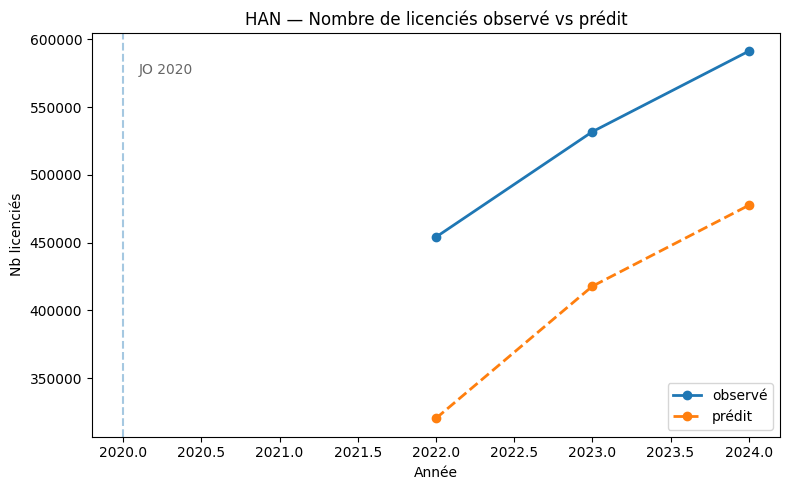

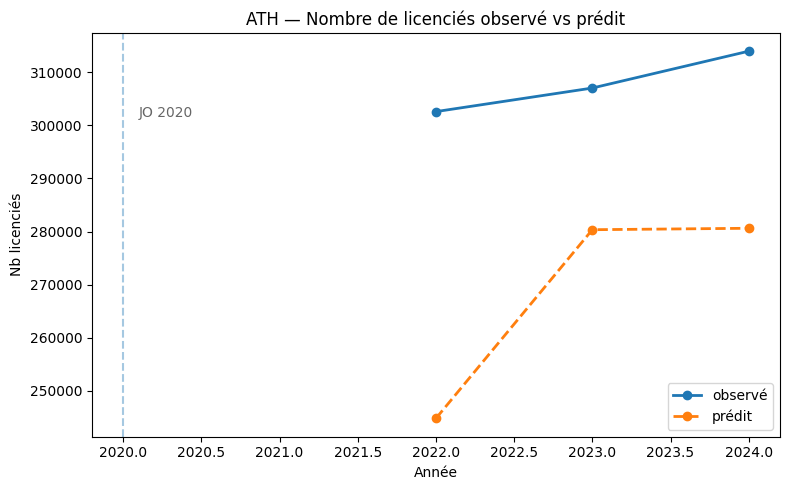

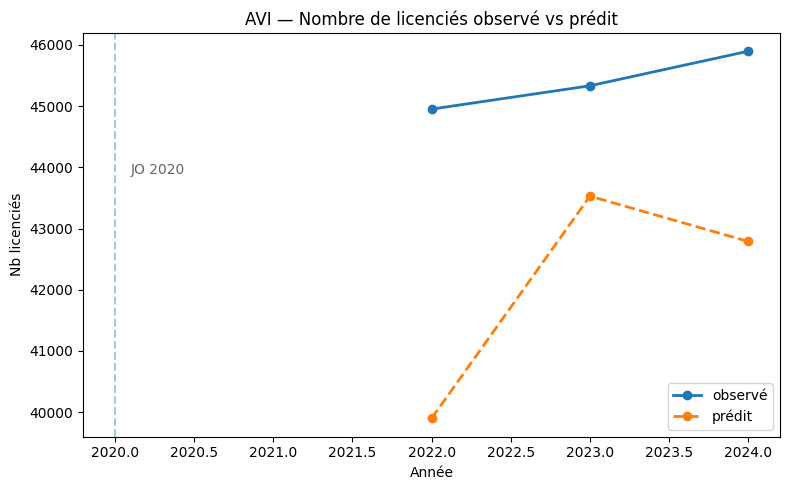

,code_sport,annee,nb_licencies,pred_nb_licencies
15,AVI,2022,44951,39898.025214
16,AVI,2023,45332,43528.426796
17,AVI,2024,45897,42787.773178


In [76]:
plot_pred_sport("HAN")   # Handball
plot_pred_sport("ATH")   # Athlétisme
plot_pred_sport("AVI")   # Aviron


In [77]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

def fit_medal_effect_by_sport(df_model_full: pd.DataFrame,
                              medals_col: str = "nb_med_last_jo",
                              y_col: str = "nb_licencies",
                              sport_col: str = "code_sport",
                              year_col: str = "annee",
                              min_year: int = 2017,
                              max_year: int = 2024):
    """
    Estime un modèle économétrique où l'effet des médailles peut différer par sport:
    dlog(1+lic) ~ medals + C(sport) + C(year) + medals:C(sport)
    SE clusterisées par sport.
    
    Retourne l'objet results statsmodels.
    """

    df = df_model_full.copy()

    # --- sécurité colonnes
    needed = [medals_col, y_col, sport_col, year_col]
    miss = [c for c in needed if c not in df.columns]
    if miss:
        raise ValueError(f"Colonnes manquantes: {miss}")

    # --- fenêtre temporelle
    df = df[df[year_col].between(min_year, max_year)].copy()

    # --- dlog(1+lic)
    df = df.sort_values([sport_col, year_col])
    df["log_lic"] = np.log1p(pd.to_numeric(df[y_col], errors="coerce"))
    df["dlog_lic"] = df.groupby(sport_col)["log_lic"].diff(1)

    # --- medals numeric
    df[medals_col] = pd.to_numeric(df[medals_col], errors="coerce").fillna(0)

    # --- drop NA diff
    df = df.dropna(subset=["dlog_lic"]).copy()

    # --- modèle avec interaction (effet médailles par sport)
    formula = f"dlog_lic ~ {medals_col} + C({sport_col}) + C({year_col}) + {medals_col}:C({sport_col})"
    res = smf.ols(formula, data=df).fit(cov_type="cluster", cov_kwds={"groups": df[sport_col]})

    return res


def causal_effect_lastJO_for_sport(res, code_sport: str,
                                  medals_col: str = "nb_med_last_jo",
                                  sport_col: str = "code_sport"):
    """
    Donne l'effet marginal des médailles (Δlog(1+lic)) pour UN sport.
    Effet(sport) = beta_medals + beta_interaction(sport), avec SE/p-value/IC.
    
    Retour: dict clair à mettre dans ton rapport.
    """

    params = res.params
    cov = res.cov_params()

    base = medals_col
    inter = f"{medals_col}:C({sport_col})[T.{code_sport}]"

    # Si c'est la catégorie de référence, pas de terme d'interaction
    beta = float(params.get(base, 0.0)) + float(params.get(inter, 0.0))

    # Variance(beta) = Var(base) + Var(inter) + 2Cov(base, inter)
    var = float(cov.loc[base, base]) if base in cov.index else 0.0
    if inter in cov.index:
        var += float(cov.loc[inter, inter])
        if base in cov.index:
            var += 2.0 * float(cov.loc[base, inter])

    se = float(np.sqrt(max(var, 0.0))) if var > 0 else np.nan
    z = beta / se if (se is not None and not np.isnan(se) and se > 0) else np.nan

    # p-value approx normale
    try:
        from scipy.stats import norm
        pval = 2 * (1 - norm.cdf(abs(z))) if not np.isnan(z) else np.nan
        ci_low = beta - 1.96 * se if not np.isnan(se) else np.nan
        ci_high = beta + 1.96 * se if not np.isnan(se) else np.nan
    except Exception:
        pval, ci_low, ci_high = np.nan, np.nan, np.nan

    # interprétation en %
    # dlog ≈ % croissance (approx)
    return {
        "sport": code_sport,
        "effect_per_medal_dlog": beta,
        "effect_per_medal_pct_approx": 100 * beta,   # ex: 0.002 -> 0.2%
        "se": se,
        "p_value": pval,
        "ci95_dlog": (ci_low, ci_high),
        "ci95_pct_approx": (100 * ci_low, 100 * ci_high) if (ci_low==ci_low and ci_high==ci_high) else (np.nan, np.nan),
        "note": "Effet = variation de la croissance annuelle (Δlog(1+lic)) par médaille."
    }


# ======================
# UTILISATION (3 lignes)
# ======================
# 1) Fit une fois
# res_by_sport = fit_medal_effect_by_sport(df_model_full, medals_col="nb_med_last_jo")

# 2) Effet causal estimé pour un sport
# causal_effect_lastJO_for_sport(res_by_sport, "HAN")

# 3) Pareil pour ATH / AVI
# causal_effect_lastJO_for_sport(res_by_sport, "ATH")
# causal_effect_lastJO_for_sport(res_by_sport, "AVI")


In [81]:
print(df_model_full.columns)
df_model_full.head()


Index(['code_sport', 'annee', 'nb_licencies', 'jo_ref', 'or', 'argent',
       'bronze', 'total_medailles', 'nb_femmes', 'nb_hommes', 'age_mean',
       'age_std', 'nb_lt14', 'nb_14_17', 'nb_18_34', 'nb_35_49', 'nb_50p',
       'tranche_1_-_enfants_(1-13)', 'tranche_2_-_jeunes_(14-20)',
       'tranche_3_-_adultes_(21-55)', 'tranche_4_-_seniors_(56-99)',
       'tranche_nr_-_non_réparti', 'nb_departements_actifs', 'herfindahl_dep',
       'part_femmes', 'part_hommes', 'part_lt14', 'part_14_17', 'part_18_34',
       'part_35_49', 'part_50p', 'nb_licencies_lag1', 'part_femmes_lag1',
       'age_mean_lag1', 'nb_licencies_lag2', 'part_femmes_lag2',
       'age_mean_lag2', 'croissance_lag1', 'croissance_lag2',
       'nb_licencies_roll2'],
      dtype='object')


,code_sport,annee,nb_licencies,jo_ref,or,argent,bronze,total_medailles,nb_femmes,nb_hommes,...,part_50p,nb_licencies_lag1,part_femmes_lag1,age_mean_lag1,nb_licencies_lag2,part_femmes_lag2,age_mean_lag2,croissance_lag1,croissance_lag2,nb_licencies_roll2
0,ATH,2016,301976,2016,0.0,3.0,3.0,6.0,141983,159993,...,0.186969,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ATH,2017,307018,2016,0.0,3.0,3.0,6.0,146532,160486,...,0.192354,301976.0,0.470180,28.460622,NaN,NaN,NaN,0.016697,NaN,NaN
2,ATH,2018,314692,2016,0.0,3.0,3.0,6.0,147945,165753,...,0.197870,307018.0,0.477275,28.641338,301976.0,0.470180,28.460622,0.024995,0.016697,304497.0
3,ATH,2019,316749,2016,0.0,3.0,3.0,6.0,150440,166309,...,0.204016,314692.0,0.470126,28.724186,307018.0,0.477275,28.641338,0.006537,0.024995,310855.0
4,ATH,2020,305914,2020,0.0,1.0,0.0,1.0,144038,161876,...,0.214416,316749.0,0.474950,29.010014,314692.0,0.470126,28.724186,-0.034207,0.006537,315720.5


In [83]:
res_by_sport = fit_medal_effect_by_sport(df_model_full, medals_col="total_medailles")
causal_effect_lastJO_for_sport(res_by_sport, "HAN", medals_col="total_medailles")



{'sport': 'HAN',
 'effect_per_medal_dlog': -0.09026500484817537,
 'effect_per_medal_pct_approx': -9.026500484817538,
 'se': 0.018617984243805535,
 'p_value': 1.245431411556197e-06,
 'ci95_dlog': (-0.12675625396603424, -0.05377375573031652),
 'ci95_pct_approx': (-12.675625396603424, -5.377375573031652),
 'note': 'Effet = variation de la croissance annuelle (Δlog(1+lic)) par médaille.'}

In [86]:
causal_effect_lastJO_for_sport(res_by_sport, "AVI", medals_col="total_medailles")


{'sport': 'AVI',
 'effect_per_medal_dlog': 0.0012535060891215631,
 'effect_per_medal_pct_approx': 0.12535060891215632,
 'se': 0.009308992121902847,
 'p_value': 0.8928843349101758,
 'ci95_dlog': (-0.01699211846980802, 0.019499130648051144),
 'ci95_pct_approx': (-1.699211846980802, 1.9499130648051144),
 'note': 'Effet = variation de la croissance annuelle (Δlog(1+lic)) par médaille.'}

In [87]:
causal_effect_lastJO_for_sport(res_by_sport, "ATH", medals_col="total_medailles")



{'sport': 'ATH',
 'effect_per_medal_dlog': 0.007377169433296305,
 'effect_per_medal_pct_approx': 0.7377169433296306,
 'se': 0.0025974921430635236,
 'p_value': 0.004509765201487825,
 'ci95_dlog': (0.0022860848328917997, 0.012468254033700811),
 'ci95_pct_approx': (0.22860848328917996, 1.2468254033700812),
 'note': 'Effet = variation de la croissance annuelle (Δlog(1+lic)) par médaille.'}

L’impact des performances olympiques sur la dynamique des licenciés est hétérogène selon les sports. Alors que l’athlétisme bénéficie d’un effet positif et significatif des médailles olympiques sur la croissance de ses licenciés, aucun effet n’est détecté pour l’aviron. À l’inverse, le handball présente un effet négatif significatif, interprétable comme un phénomène de saturation après une phase de forte exposition médiatique.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error

# =========================
# PREUVE INERTIE > JO : ablation
# suppose df_model_full existe déjà
# colonnes : code_sport, annee, nb_licencies, total_medailles, nb_licencies_lag1, etc.
# =========================

df_work = df_model_full.copy()

# cible en log (plus stable)
df_work["log_y"] = np.log1p(df_work["nb_licencies"])

# garder lignes avec lag1 dispo
df_work = df_work.dropna(subset=["nb_licencies_lag1"]).copy()
df_work["log_lag1"] = np.log1p(df_work["nb_licencies_lag1"])

# split temporel (comme toi)
train_df = df_work[(df_work["annee"] >= 2017) & (df_work["annee"] <= 2020)].copy()
test_df  = df_work[(df_work["annee"] >= 2022) & (df_work["annee"] <= 2024)].copy()

# fonctions utiles
def fit_eval(features, name):
    Xtr = pd.get_dummies(train_df[features], columns=["code_sport"], drop_first=True)
    Xte = pd.get_dummies(test_df[features], columns=["code_sport"], drop_first=True)
    Xte = Xte.reindex(columns=Xtr.columns, fill_value=0)

    ytr = train_df["log_y"].values
    yte = test_df["log_y"].values

    model = Ridge(alpha=1.0)
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)

    r2 = r2_score(yte, pred)
    mae = mean_absolute_error(np.expm1(yte), np.expm1(pred))
    return {"model": name, "R2_log": r2, "MAE_niveau": mae}

# 3 modèles emboîtés
res = []
res.append(fit_eval(["code_sport", "log_lag1"], "M0: inertie seule (lag1)"))
#res.append(fit_eval(["code_sport", "total_medailles"], "M1: médailles seules"))
res.append(fit_eval(["code_sport", "log_lag1", "total_medailles"], "M2: inertie + médailles"))

pd.DataFrame(res)


,model,R2_log,MAE_niveau
0,M0: inertie seule (lag1),0.989764,49220.355231
1,M2: inertie + médailles,0.989602,49868.072192


RQ: quasi pas de différence entre M0 et M2 donc les médailles n'expliquent pas (juste forte corrélation askip)
Bien que les médailles olympiques expliquent une part importante de la variance du nombre de licenciés lorsqu’elles sont considérées seules, ce modèle présente de très mauvaises performances prédictives hors-échantillon. Cela s’explique par l’absence de prise en compte de la taille initiale des sports. Les médailles sont fortement corrélées à la popularité historique d’un sport, mais ne suffisent pas à expliquer son niveau de licenciés. L’ajout d’une variable d’inertie permet de corriger ce biais en capturant l’échelle propre à chaque discipline.

In [91]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

df_work = df_model_full.dropna(subset=["nb_licencies_lag1"]).copy()
df_work["log_y"] = np.log1p(df_work["nb_licencies"])
df_work["log_lag1"] = np.log1p(df_work["nb_licencies_lag1"])

train_df = df_work[(df_work["annee"] >= 2017) & (df_work["annee"] <= 2020)].copy()

features_num = ["log_lag1", "total_medailles"]
features_cat = ["code_sport"]

X = train_df[features_num + features_cat]
y = train_df["log_y"].values

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), features_num),
        ("cat", "passthrough", features_cat),
    ],
    remainder="drop"
)

# dummies dans pipeline via get_dummies simple
X_dum = pd.get_dummies(X, columns=["code_sport"], drop_first=True)

pipe = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),  # safe car sparse possible
    ("ridge", Ridge(alpha=1.0))
])

pipe.fit(X_dum, y)

coef = pd.Series(pipe.named_steps["ridge"].coef_, index=X_dum.columns).sort_values(key=np.abs, ascending=False)
coef.head(15)


log_lag1          0.849822
code_sport_PEN   -0.360608
code_sport_DIV    0.267001
code_sport_BAS   -0.218733
code_sport_SUR   -0.217198
code_sport_HOC   -0.203474
code_sport_LUT   -0.184365
code_sport_HAL   -0.178132
code_sport_FOO    0.174226
code_sport_AVI   -0.134617
code_sport_BOX   -0.120977
code_sport_TAE   -0.119757
code_sport_ESC   -0.119285
code_sport_TEN    0.112856
code_sport_TRI   -0.108781
dtype: float64

In [92]:
import statsmodels.formula.api as smf

dfw = df_model_full.dropna(subset=["nb_licencies_lag1"]).copy()
dfw["log_y"] = np.log1p(dfw["nb_licencies"])
dfw["log_lag1"] = np.log1p(dfw["nb_licencies_lag1"])

train_df = dfw[(dfw["annee"] >= 2017) & (dfw["annee"] <= 2020)].copy()

m0 = smf.ols("log_y ~ log_lag1 + C(code_sport)", data=train_df).fit()
m2 = smf.ols("log_y ~ log_lag1 + total_medailles + C(code_sport)", data=train_df).fit()

print("R2 m0:", m0.rsquared, " | R2 m2:", m2.rsquared)
print(m2.compare_f_test(m0))  # (F, p-value, df_diff)


R2 m0: 0.9991231621392457  | R2 m2: 0.9991286020800678
(0.6242774624174572, 0.4313318297180274, 1.0)


Les résultats montrent que la dynamique du nombre de licenciés est principalement auto-régressive. Si les médailles olympiques sont corrélées à l’évolution des effectifs, elles n’apportent pas de pouvoir explicatif additionnel significatif une fois l’inertie et les effets fixes par sport pris en compte. En revanche, des analyses désagrégées par sport suggèrent une hétérogénéité des effets, ce qui justifie une analyse complémentaire au niveau disciplinaire.